# Sustituciones

Una simulación de fútbol necesita decidir **cuántos cambios habrá, cuándo ocurrirán y qué jugadores participarán**. Este notebook reconstruye esa metodología con datos históricos de Barcelona y Real Madrid guardados en CSV.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 12, "axes.titleweight": "bold",
})

def finish_chart(fig, subtitle, subtitle_y=0.90):
    fig.text(0.06, subtitle_y, subtitle, fontsize=10.5, color=MUTED, ha="left")

def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

DATA_PATH = DATA_DIR / "substitutions_barca_real_madrid.csv"
subs = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
subs["match_date"] = pd.to_datetime(subs["match_date"])

nullable_ints = ["sub_in", "sub_out"]
for column in nullable_ints:
    subs[column] = pd.to_numeric(subs[column], errors="coerce")

required_columns = {
    "match_id", "match_date", "league_id", "league_name", "home_team_id", "home_team",
    "away_team_id", "away_team", "team_id", "team", "is_home", "player_id",
    "sub_in", "sub_out", "in_status", "out_status", "match_minutes_played",
    "off_xg_coef", "def_xg_coef", "fatigue", "rhythm", "career_minutes_snapshot",
}
assert required_columns.issubset(subs.columns)
assert not subs.duplicated(["match_id", "player_id"]).any()
assert set(subs["team_id"].unique()) == {30, 31}
assert subs[["match_id", "match_date", "team_id", "team", "player_id"]].notna().all().all()
assert (subs["match_minutes_played"] >= 0).all()


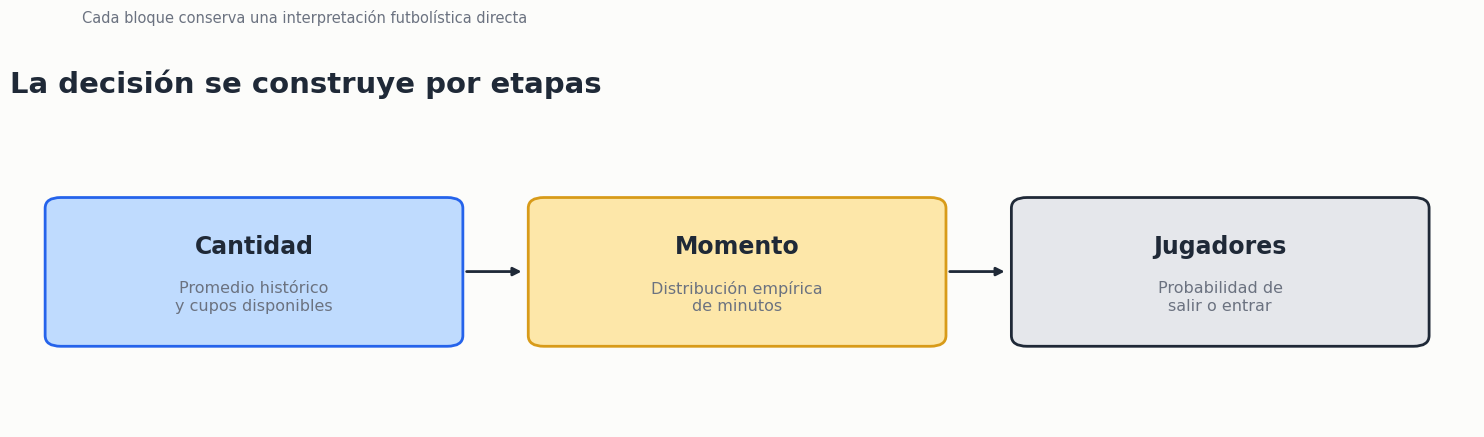

In [2]:
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4.8)
ax.axis("off")

boxes = [
    (0.4, "Cantidad", "Promedio histórico\ny cupos disponibles", BLUE_LIGHT, BLUE),
    (5.35, "Momento", "Distribución empírica\nde minutos", GOLD_LIGHT, GOLD),
    (10.3, "Jugadores", "Probabilidad de\nsalir o entrar", "#E5E7EB", INK),
]
for x, title, subtitle, fill, edge in boxes:
    patch = FancyBboxPatch((x, 1.25), 4.2, 2.15, boxstyle="round,pad=0.04,rounding_size=0.16",
                           facecolor=fill, edgecolor=edge, linewidth=2)
    ax.add_patch(patch)
    ax.text(x + 2.1, 2.7, title, ha="center", va="center", fontsize=17, fontweight="bold")
    ax.text(x + 2.1, 1.95, subtitle, ha="center", va="center", fontsize=11.5, color=MUTED)
for start in (4.65, 9.6):
    ax.annotate("", xy=(start + 0.62, 2.33), xytext=(start, 2.33),
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=2))
ax.set_title("La decisión se construye por etapas", loc="left", fontsize=21, pad=10)
finish_chart(fig, "Cada bloque conserva una interpretación futbolística directa", subtitle_y=0.88)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()


## Datos reales

In [3]:
coverage = pd.Series({
    "Filas jugador-partido": f"{len(subs):,}",
    "Partidos": f"{subs['match_id'].nunique():,}",
    "Jugadores": f"{subs['player_id'].nunique():,}",
    "Sustituciones registradas": f"{subs['sub_in'].notna().sum():,}",
    "Primera fecha": subs["match_date"].min().strftime("%d/%m/%Y"),
    "Última fecha": subs["match_date"].max().strftime("%d/%m/%Y"),
}, name="Cobertura")
display(coverage.to_frame())

preview_columns = [
    "match_date", "home_team", "away_team", "team", "player_id",
    "sub_in", "sub_out", "in_status", "out_status", "match_minutes_played",
]
display(subs.loc[subs["sub_in"].notna(), preview_columns].head(8))


,Cobertura
Filas jugador-partido,"5,747"
Partidos,282
Jugadores,87
Sustituciones registradas,842
Primera fecha,30/12/2022
Última fecha,18/09/2025


,match_date,home_team,away_team,team,player_id,sub_in,sub_out,in_status,out_status,match_minutes_played
2,2022-12-30 21:30:00,Equipo histórico 364,Real Madrid,Real Madrid,Aurélien Tchouaméni_14_RM,87.0,NaN,leading,NaN,10
7,2022-12-30 21:30:00,Equipo histórico 364,Real Madrid,Real Madrid,Eduardo Camavinga_6_RM,69.0,NaN,level,NaN,28
12,2022-12-30 21:30:00,Equipo histórico 364,Real Madrid,Real Madrid,Lucas Vázquez_17_RM,60.0,NaN,level,NaN,37
13,2022-12-30 21:30:00,Equipo histórico 364,Real Madrid,Real Madrid,Luka Modrić_10_RM,88.0,NaN,leading,NaN,9
16,2022-12-30 21:30:00,Equipo histórico 364,Real Madrid,Real Madrid,Rodrygo_11_RM,60.0,NaN,level,NaN,37
21,2022-12-31 14:00:00,Barcelona,Equipo histórico 200,Barcelona,Alejandro Balde_3_B,82.0,NaN,level,NaN,18
25,2022-12-31 14:00:00,Barcelona,Equipo histórico 200,Barcelona,Ferrán Torres_7_B,62.0,NaN,leading,NaN,38
30,2022-12-31 14:00:00,Barcelona,Equipo histórico 200,Barcelona,Jules Koundé_23_B,82.0,NaN,level,NaN,18


## ¿Cuántos cambios suele hacer cada equipo?


,Partidos,Promedio,Mediana,Máximo
team,,,,
Barcelona,136,3.10,4.0,6
Real Madrid,143,2.71,3.0,5


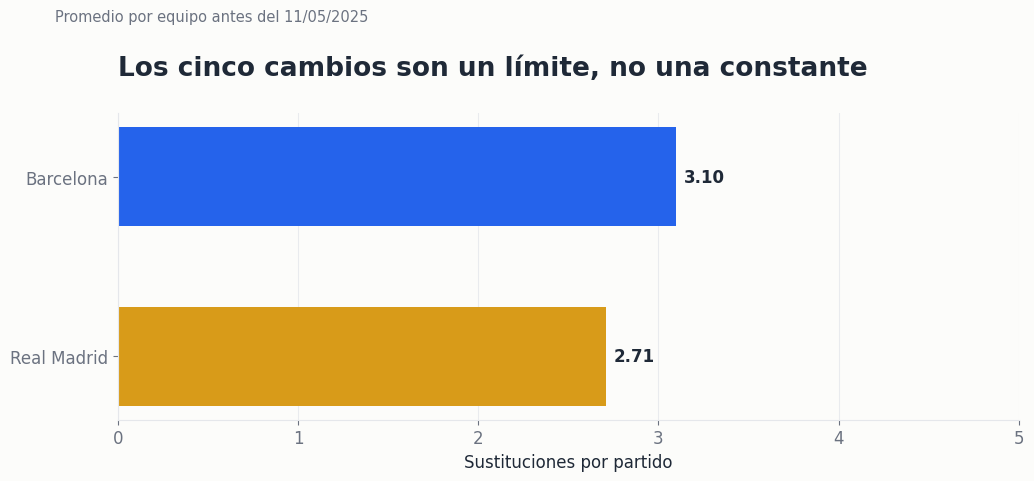

In [4]:
EXAMPLE_ID = 28055
EXAMPLE_DATE = pd.Timestamp("2025-05-11")
history = subs[subs["match_date"] < EXAMPLE_DATE].copy()

team_matches = (
    history.assign(change=history["sub_in"].notna().astype(int))
    .groupby(["team", "match_id"], as_index=False)["change"].sum()
)
sub_summary = (
    team_matches.groupby("team")["change"]
    .agg(Partidos="size", Promedio="mean", Mediana="median", Máximo="max")
    .round(2)
)
display(sub_summary)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
plot_values = sub_summary["Promedio"].sort_values()
team_colors = {"Barcelona": BLUE, "Real Madrid": GOLD}
bars = ax.barh(plot_values.index, plot_values.values, color=[team_colors[team] for team in plot_values.index], height=0.55)
for bar, value in zip(bars, plot_values.values):
    ax.text(value + 0.04, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", fontweight="bold")
ax.set_xlim(0, max(5, plot_values.max() + 0.6))
ax.set_xlabel("Sustituciones por partido")
ax.set_title("Los cinco cambios son un límite, no una constante", loc="left", fontsize=19, pad=28)
clean_axes(ax, grid_axis="x")
finish_chart(fig, "Promedio por equipo antes del 11/05/2025", subtitle_y=0.90)
plt.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()


## ¿Cuándo suelen ocurrir?


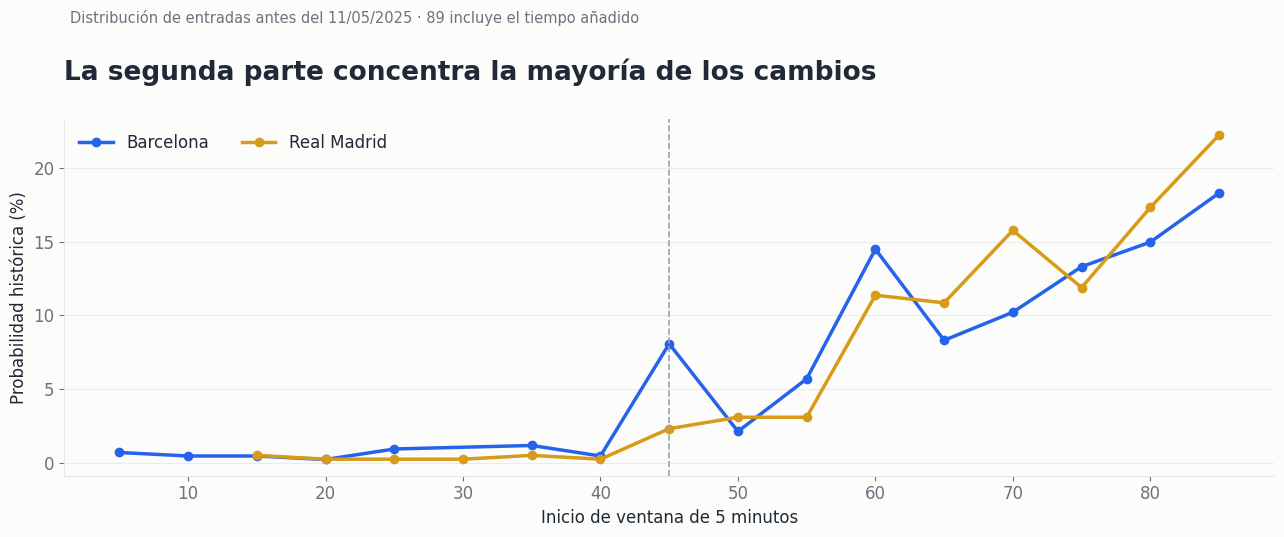

,Equipo,Ventana,Probabilidad
0,Barcelona,85,18.3%
1,Barcelona,80,15.0%
2,Barcelona,60,14.5%
3,Real Madrid,85,22.2%
4,Real Madrid,80,17.3%
5,Real Madrid,70,15.8%


In [5]:
minute_events = history.loc[history["sub_in"].notna(), ["team", "sub_in"]].copy()
minute_events["minute"] = minute_events["sub_in"].clip(upper=89).astype(int)
minute_events["window"] = (minute_events["minute"] // 5 * 5).clip(upper=85)
minute_distribution = (
    minute_events.groupby(["team", "window"]).size().rename("count").reset_index()
)
minute_distribution["probability"] = minute_distribution.groupby("team")["count"].transform(lambda s: s / s.sum())

fig, ax = plt.subplots(figsize=(13, 5.8))
for team, color in [("Barcelona", BLUE), ("Real Madrid", GOLD)]:
    team_curve = minute_distribution[minute_distribution["team"] == team]
    ax.plot(team_curve["window"], team_curve["probability"] * 100, marker="o", lw=2.5,
            color=color, label=team)
ax.axvline(45, color=GREY, linestyle="--", linewidth=1.2)
ax.set_xlabel("Inicio de ventana de 5 minutos")
ax.set_ylabel("Probabilidad histórica (%)")
ax.set_title("La segunda parte concentra la mayoría de los cambios", loc="left", fontsize=19, pad=28)
ax.legend(frameon=False, ncol=2, loc="upper left")
clean_axes(ax)
finish_chart(fig, "Distribución de entradas antes del 11/05/2025 · 89 incluye el tiempo añadido", subtitle_y=0.90)
plt.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()

top_windows = (
    minute_distribution.sort_values(["team", "probability"], ascending=[True, False])
    .groupby("team").head(3)
    .assign(Probabilidad=lambda x: (x["probability"] * 100).round(1).astype(str) + "%")
    .rename(columns={"team": "Equipo", "window": "Ventana"})
)
display(top_windows[["Equipo", "Ventana", "Probabilidad"]].reset_index(drop=True))


## El marcador reordena a los jugadores

Ahora la pregunta es individual: ante el mismo grupo de titulares y suplentes, ¿quién gana o pierde probabilidad cuando el equipo pasa de ir perdiendo a ir ganando?

La heurística combina tres señales fáciles de auditar:

- **Historial:** frecuencia con la que el jugador ha salido o entrado y contexto de esos cambios.
- **Jerarquía:** minutos acumulados; protege a titulares habituales y reconoce a suplentes recurrentes.
- **Táctica:** perdiendo se prioriza el perfil ofensivo; ganando se prioriza el defensivo.

Lo importante es verificar el efecto de esas tres señales: **cómo cambia el ranking de cada jugador bajo dos marcadores distintos**. Usamos las convocatorias del Clásico como un plantel fijo, pero todavía no miramos quién fue sustituido realmente.

In [6]:
STATUS_LABELS = {"Trailing": "trailing", "Level": "level", "Leading": "leading"}
status_order = ["trailing", "level", "leading"]
TACTICAL_WEIGHTS = {
    "Trailing": (0.8, 0.2),
    "Level": (0.5, 0.5),
    "Leading": (0.2, 0.8),
}

def laplace_status_probability(events, status):
    normalized = events.dropna().astype(str).str.lower()
    counts = normalized.value_counts().reindex(status_order, fill_value=0) + 1
    return float(counts[STATUS_LABELS[status]] / counts.sum())

def player_profile(player_id, cutoff):
    player_rows = subs[(subs["player_id"] == player_id) & (subs["match_date"] < cutoff)]
    snapshot_rows = subs[subs["player_id"] == player_id]
    if snapshot_rows.empty:
        return {
            "minutes": 0.0, "sub_in_count": 0, "sub_out_count": 0,
            "in_events": pd.Series(dtype="object"), "out_events": pd.Series(dtype="object"),
            "off_coef": 0.0, "def_coef": 0.0,
        }
    snapshot = snapshot_rows.iloc[-1]
    return {
        "minutes": float(player_rows["match_minutes_played"].sum()),
        "sub_in_count": int(player_rows["sub_in"].notna().sum()),
        "sub_out_count": int(player_rows["sub_out"].notna().sum()),
        "in_events": player_rows.loc[player_rows["sub_in"].notna(), "in_status"],
        "out_events": player_rows.loc[player_rows["sub_out"].notna(), "out_status"],
        "off_coef": float(snapshot["off_xg_coef"]) if pd.notna(snapshot["off_xg_coef"]) else 0.0,
        "def_coef": float(snapshot["def_xg_coef"]) if pd.notna(snapshot["def_xg_coef"]) else 0.0,
    }

def substitution_probabilities(players, status, mode, cutoff=EXAMPLE_DATE):
    if mode not in {"in", "out"}:
        raise ValueError("mode debe ser 'in' o 'out'")
    if not players:
        return pd.DataFrame(columns=["player_id", "probability", "rank"])

    off_weight, def_weight = TACTICAL_WEIGHTS[status]
    rows = []
    for player_id in players:
        profile = player_profile(player_id, cutoff)
        events = profile[f"{mode}_events"]
        history_count = profile[f"sub_{mode}_count"]
        status_probability = laplace_status_probability(events, status)
        tactical = profile["off_coef"] * off_weight + profile["def_coef"] * def_weight
        tactical_base = max(0.001, 0.1 + tactical)

        if mode == "out":
            hierarchy = 1 / ((profile["minutes"] / 100) + 1) ** 2
            tactical_factor = 1 / tactical_base
        else:
            hierarchy = (profile["minutes"] / 100) + 1
            tactical_factor = tactical_base

        score = (history_count + 1) * status_probability * hierarchy * tactical_factor
        rows.append({
            "player_id": player_id,
            "history_count": history_count,
            "status_probability": status_probability,
            "hierarchy": hierarchy,
            "tactical_factor": tactical_factor,
            "score": score,
        })

    result = pd.DataFrame(rows)
    valid_total = result["score"].replace([np.inf, -np.inf], np.nan).dropna().sum()
    result["probability"] = 1 / len(result) if not np.isfinite(valid_total) or valid_total <= 0 else result["score"] / valid_total
    result = result.sort_values("probability", ascending=False).reset_index(drop=True)
    result["rank"] = np.arange(1, len(result) + 1)

    assert np.isfinite(result[["score", "probability"]]).all().all()
    assert (result[["score", "probability"]] >= 0).all().all()
    assert np.isclose(result["probability"].sum(), 1.0)
    return result

def short_name(player_id):
    return player_id.rsplit("_", 2)[0]


In [7]:
clasico = subs[subs["match_id"] == EXAMPLE_ID].copy()
assert clasico["home_team"].nunique() == 1 and clasico["home_team"].iloc[0] == "Barcelona"
assert clasico["away_team"].nunique() == 1 and clasico["away_team"].iloc[0] == "Real Madrid"
assert len(clasico) == 44
assert (clasico["match_minutes_played"] > 0).sum() == 31
assert clasico["sub_in"].notna().sum() == 9

def match_pools(team):
    team_rows = clasico[clasico["team"] == team]
    starters = team_rows.loc[
        team_rows["sub_in"].isna() & (team_rows["match_minutes_played"] > 0), "player_id"
    ].tolist()
    bench = team_rows.loc[~team_rows["player_id"].isin(starters), "player_id"].tolist()
    return starters, bench

barcelona_starters, barcelona_bench = match_pools("Barcelona")
madrid_starters, madrid_bench = match_pools("Real Madrid")
assert len(barcelona_starters) == 11 and len(madrid_starters) == 11

candidate_groups = {
    "Real Madrid · candidato a salir": (madrid_starters, "out"),
    "Real Madrid · candidato a entrar": (madrid_bench, "in"),
    "Barcelona · candidato a salir": (barcelona_starters, "out"),
    "Barcelona · candidato a entrar": (barcelona_bench, "in"),
}

def compare_score_states(players, mode):
    trailing = substitution_probabilities(players, "Trailing", mode)[["player_id", "probability"]]
    leading = substitution_probabilities(players, "Leading", mode)[["player_id", "probability"]]
    return (
        trailing.merge(leading, on="player_id", suffixes=("_trailing", "_leading"))
        .assign(mean_probability=lambda frame: frame[["probability_trailing", "probability_leading"]].mean(axis=1))
        .sort_values("mean_probability")
    )

score_state_tables = {
    title: compare_score_states(players, mode)
    for title, (players, mode) in candidate_groups.items()
}


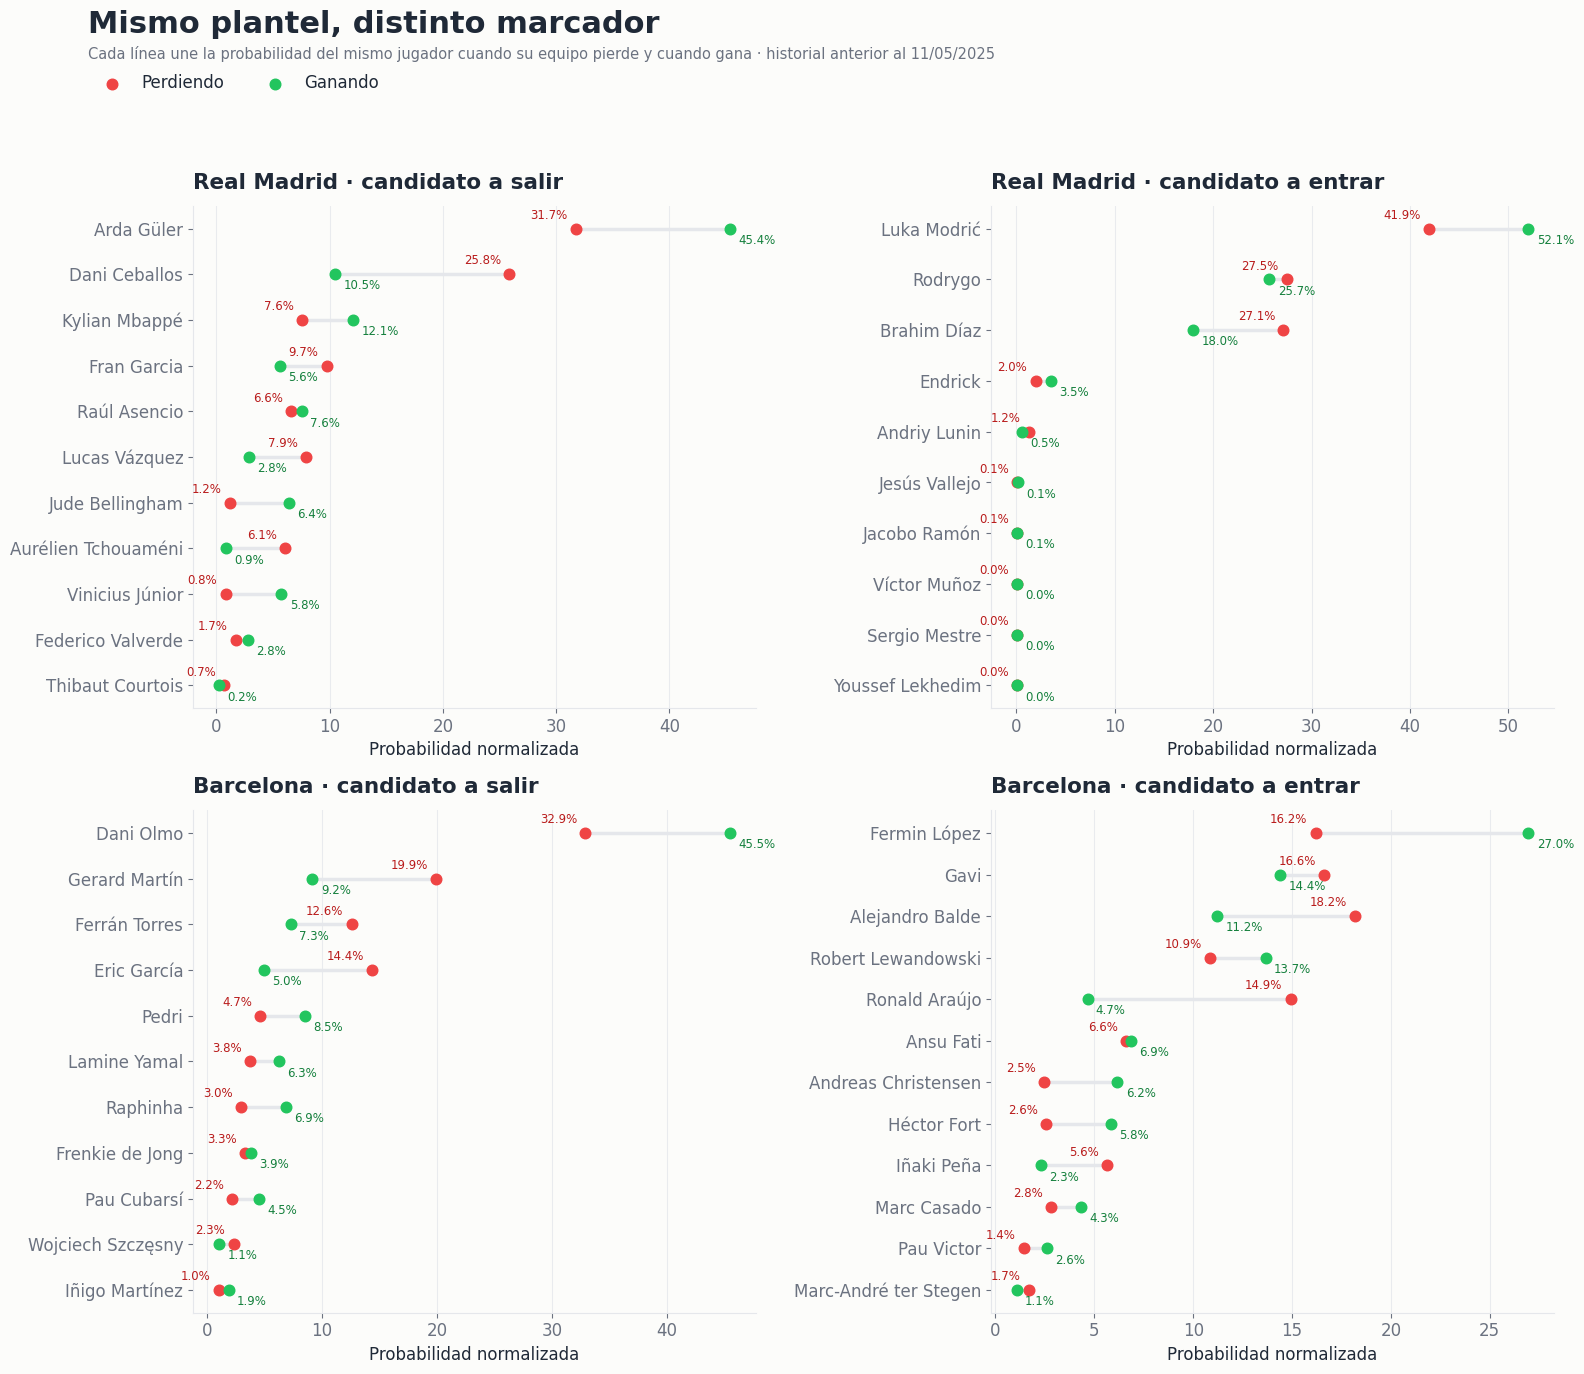

,Grupo,Más favorecido perdiendo,Variación perdiendo (p.p.),Más favorecido ganando,Variación ganando (p.p.)
0,Real Madrid · candidato a salir,Dani Ceballos,+15.3,Arda Güler,+13.7
1,Real Madrid · candidato a entrar,Brahim Díaz,+9.2,Luka Modrić,+10.1
2,Barcelona · candidato a salir,Gerard Martín,+10.8,Dani Olmo,+12.6
3,Barcelona · candidato a entrar,Ronald Araújo,+10.3,Fermin López,+10.8


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (title, table) in zip(axes.flat, score_state_tables.items()):
    shown = table.reset_index(drop=True)
    y = np.arange(len(shown))
    trailing = shown["probability_trailing"] * 100
    leading = shown["probability_leading"] * 100

    for position, lose_value, win_value in zip(y, trailing, leading):
        ax.plot([lose_value, win_value], [position, position], color=GRID, linewidth=2.5, zorder=1)
    ax.scatter(trailing, y, color="#EF4444", s=58, label="Perdiendo", zorder=2)
    ax.scatter(leading, y, color="#22C55E", s=58, label="Ganando", zorder=2)

    for position, value in zip(y, trailing):
        ax.annotate(f"{value:.1f}%", (value, position), xytext=(-6, 7), textcoords="offset points",
                    ha="right", fontsize=8.5, color="#B91C1C")
    for position, value in zip(y, leading):
        ax.annotate(f"{value:.1f}%", (value, position), xytext=(6, -11), textcoords="offset points",
                    ha="left", fontsize=8.5, color="#15803D")

    ax.set_yticks(y, shown["player_id"].map(short_name))
    ax.set_xlabel("Probabilidad normalizada")
    ax.set_title(title, loc="left", fontsize=15.5, pad=12)
    clean_axes(ax, grid_axis="x")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0.055, 0.945))
fig.suptitle("Mismo plantel, distinto marcador", x=0.06, ha="left", fontsize=22, fontweight="bold")
finish_chart(
    fig,
    "Cada línea une la probabilidad del mismo jugador cuando su equipo pierde y cuando gana · historial anterior al 11/05/2025",
    subtitle_y=0.945,
)
plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

leaders = []
for title, table in score_state_tables.items():
    changes = table.assign(
        change_if_trailing=lambda frame: frame["probability_trailing"] - frame["probability_leading"],
        change_if_leading=lambda frame: frame["probability_leading"] - frame["probability_trailing"],
    )
    favored_trailing = changes.nlargest(1, "change_if_trailing").iloc[0]
    favored_leading = changes.nlargest(1, "change_if_leading").iloc[0]
    leaders.append({
        "Grupo": title,
        "Más favorecido perdiendo": short_name(favored_trailing["player_id"]),
        "Variación perdiendo (p.p.)": favored_trailing["change_if_trailing"],
        "Más favorecido ganando": short_name(favored_leading["player_id"]),
        "Variación ganando (p.p.)": favored_leading["change_if_leading"],
    })

leaders = pd.DataFrame(leaders)
display(
    leaders.style.format({
        "Variación perdiendo (p.p.)": lambda value: f"{value * 100:+.1f}",
        "Variación ganando (p.p.)": lambda value: f"{value * 100:+.1f}",
    })
)


## El Clásico

In [9]:
STATE_FOR_MODEL = {
    "trailing": "Trailing",
    "level": "Level",
    "leading": "Leading",
}
STATE_IN_SPANISH = {
    "trailing": "Perdiendo",
    "level": "Empatando",
    "leading": "Ganando",
}

available_players = {
    "Barcelona": {"field": list(barcelona_starters), "bench": list(barcelona_bench)},
    "Real Madrid": {"field": list(madrid_starters), "bench": list(madrid_bench)},
}

change_windows = (
    clasico.loc[clasico["sub_in"].notna(), ["team", "sub_in"]]
    .drop_duplicates()
    .sort_values(["sub_in", "team"])
)

window_rows = []
probability_audits = []

for team, minute in change_windows.itertuples(index=False, name=None):
    incoming_rows = clasico.loc[(clasico["team"] == team) & (clasico["sub_in"] == minute)]
    outgoing_rows = clasico.loc[(clasico["team"] == team) & (clasico["sub_out"] == minute)]
    incoming = incoming_rows["player_id"].tolist()
    outgoing = outgoing_rows["player_id"].tolist()
    assert len(incoming) == len(outgoing)

    recorded_states = pd.concat([incoming_rows["in_status"], outgoing_rows["out_status"]])
    recorded_states = recorded_states.dropna().astype(str).str.lower().unique()
    assert len(recorded_states) == 1
    state = recorded_states[0]
    model_state = STATE_FOR_MODEL[state]

    field_before = available_players[team]["field"]
    bench_before = available_players[team]["bench"]
    assert set(outgoing).issubset(field_before)
    assert set(incoming).issubset(bench_before)

    probabilities_out = substitution_probabilities(field_before, model_state, "out")
    probabilities_in = substitution_probabilities(bench_before, model_state, "in")
    probability_audits.extend([
        probabilities_out["probability"].sum(),
        probabilities_in["probability"].sum(),
    ])

    out_probability = probabilities_out.set_index("player_id")["probability"]
    in_probability = probabilities_in.set_index("player_id")["probability"]
    outgoing_text = "\n".join(
        f"{short_name(player)} — {out_probability[player]:.1%}" for player in outgoing
    )
    incoming_text = "\n".join(
        f"{short_name(player)} — {in_probability[player]:.1%}" for player in incoming
    )

    window_rows.append({
        "Minuto": int(minute),
        "Equipo": team,
        "Estado": STATE_IN_SPANISH[state],
        "Cambios": len(incoming),
        "Salieron · probabilidad de salir": outgoing_text,
        "Entraron · probabilidad de entrar": incoming_text,
    })

    available_players[team]["field"] = [player for player in field_before if player not in outgoing] + incoming
    available_players[team]["bench"] = [player for player in bench_before if player not in incoming]

window_comparison = pd.DataFrame(window_rows)
assert window_comparison["Cambios"].sum() == 9
assert len(window_comparison) == 7
assert all(np.isclose(total, 1.0) for total in probability_audits)

display(
    window_comparison.style
    .hide(axis="index")
    .set_properties(
        subset=["Salieron · probabilidad de salir", "Entraron · probabilidad de entrar"],
        **{"white-space": "pre-line", "text-align": "left"},
    )
    .set_properties(subset=["Minuto", "Estado", "Cambios"], **{"text-align": "center"})
)


Minuto,Equipo,Estado,Cambios,Salieron · probabilidad de salir,Entraron · probabilidad de entrar
46,Real Madrid,Perdiendo,2,Arda Güler — 31.7% Dani Ceballos — 25.8%,Brahim Díaz — 27.1% Luka Modrić — 41.9%
57,Barcelona,Ganando,2,Gerard Martín — 9.2% Pau Cubarsí — 4.5%,Alejandro Balde — 11.2% Andreas Christensen — 6.2%
77,Barcelona,Ganando,1,Dani Olmo — 45.0%,Fermin López — 32.6%
78,Barcelona,Ganando,1,Eric García — 7.0%,Héctor Fort — 10.4%
84,Real Madrid,Perdiendo,1,Lucas Vázquez — 12.0%,Endrick — 6.3%
88,Real Madrid,Perdiendo,1,Vinicius Júnior — 0.8%,Víctor Muñoz — 0.1%
89,Barcelona,Ganando,1,Ferrán Torres — 5.1%,Gavi — 28.9%


## Qué nos llevamos

- Cantidad y momento describen **cuántos** cambios habrá y **cuándo**; esa parte termina en la sección 4.
- El marcador entra después: no crea una nueva distribución temporal, sino que **reordena jugadores**.
- La selección combina historial, jerarquía y táctica; las probabilidades permiten ver cuánto cambia cada candidato al pasar de ir perdiendo a ir ganando.
- En el Clásico se reconstruye cada ventana con los jugadores que seguían disponibles y se contrasta directamente la probabilidad del modelo con quienes entraron y salieron.
- Es una heurística interpretable para generar decisiones plausibles, no un modelo causal ni un clasificador supervisado.

## Checks de reproducibilidad

- Fuente congelada: `02_data/substitutions_barca_real_madrid.csv`.
- Origen del extracto: `match_general`, `match_player_breakdown`, `players`, `teams` y `leagues` del respaldo `02_data/vsp.sql`.
- Equipos: Barcelona (`team_id=30`) y Real Madrid (`team_id=31`).
- Granularidad: una fila por `(match_id, player_id)`; no hay duplicados.
- Corte del ejemplo: todo agregado histórico usa fechas estrictamente anteriores al `11/05/2025`.
- Cada grupo de candidatos se normaliza de forma independiente y suma 1 tanto ganando como perdiendo.
- Caso final: `match_id=28055`, Barcelona local, Real Madrid visitante, 44 convocados, 31 participantes y 9 entradas.
- Dependencias de ejecución: Python, pandas, NumPy, Matplotlib e IPython; no requiere MySQL, credenciales ni red.